In [ ]:
import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import torch
from collections import defaultdict
from ultralytics import YOLO
from roboflow import Roboflow
import albumentations as A

# **Descarga de dataset "tesi Computer Vision Dataset" de roboflow**

In [ ]:
API_KEY_ROBOFLOW = "API_KEY_HERE"
NOMBRE_WORKSPACE = "sebastians-workspace-hr8j3"
NOMBRE_PROYECTO = "tesicomputervisiondatasetv1"
VERSION_DATASET = 1
VERSION_YOLO = "yolov8"

rf = Roboflow(api_key=API_KEY_ROBOFLOW)
project = rf.workspace(NOMBRE_WORKSPACE).project(NOMBRE_PROYECTO)
dataset = project.version(VERSION_DATASET).download(VERSION_YOLO)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to tesiComputerVisionDatasetV1-1 in yolov8:: 100%|██████████| 19176/19176 [00:03<00:00, 5966.05it/s]


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cp: cannot stat '/content/tesiComputerVisionDataset-1': No such file or directory


# **Conteo de imagenes por clase antes de DATA-AUGMENTATION:**

  **Clases:**

          -   bus: 797
          -   Construction: 1781
          -   Cyclist: 532
          -   Pedestrian: 2588
          -   Vehicle: 6515

In [ ]:
nombre_clases = ['bus','construction','cyclist','pedestrian','vehicle']

conteo_clases_imagenes_sin_DA ={i:0 for i, cadena in enumerate(nombre_clases)}

ruta_principal = "./tesiComputerVisionDataset-1/"

tipo_dataset = {'train':"train/labels"}

for clave, valor in tipo_dataset.items():
    ruta_completa = os.path.join(ruta_principal, valor)
    archivos = os.listdir(ruta_completa)

    for archivo in archivos:
        ruta_archivo = os.path.join(ruta_completa, archivo)
        apariciones_clases = set()

        with open(ruta_archivo, "r") as f:
          for linea in f:
              if linea:
                  clase_numero = int(linea[0])

                  if clase_numero not in apariciones_clases:
                      apariciones_clases.add(clase_numero)
                      conteo_clases_imagenes_sin_DA[clase_numero] += 1

print("Conteo de imagenes por clase:", conteo_clases_imagenes_sin_DA)

Conteo de imagenes por clase: {0: 797, 1: 1781, 2: 532, 3: 2588, 4: 6515}


## **Aplicación de DA:**

**Se cargan imagenes y etiquetas a las cuales se les aplicara DA**

In [ ]:
RUTA_DATASET = "./tesiComputerVisionDataset-1/"

train_images = os.path.join(RUTA_DATASET, "train/images")
train_labels = os.path.join(RUTA_DATASET, "train/labels")

**Seleccion de clases a lasque se les aplicara DA y la cantidad de imagenes se crearan por cada una**

In [ ]:
clases = [0,1,2,3]
augmmentation_x_imagen = 3

**Se definen las transformaciones**

In [ ]:
import albumentations as A

transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.4),
    A.Rotate(limit=20, p=0.5),
    A.GaussianBlur(p=0.2)
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

**Aplicación de DA**

In [ ]:
train_images
train_labels

image_files = os.listdir(train_images)

for img_file in image_files:

    img_path = os.path.join(train_images, img_file)
    label_path = os.path.join(train_labels, img_file.replace(".jpg",".txt"))

    if not os.path.exists(label_path):
        continue

    # leer labels
    with open(label_path) as f:
        lines = f.readlines()

    classes = [int(l.split()[0]) for l in lines]

    # verificar si contiene clases objetivo
    if not any(c in clases for c in classes):
        continue

    image = cv2.imread(img_path)
    h, w = image.shape[:2]

    bboxes = []
    class_labels = []

    for l in lines:
        c,x,y,bw,bh = map(float,l.split())
        bboxes.append([x,y,bw,bh])
        class_labels.append(int(c))

    for i in range(augmmentation_x_imagen):

        augmented = transform(
            image=image,
            bboxes=bboxes,
            class_labels=class_labels
        )

        aug_img = augmented["image"]
        aug_boxes = augmented["bboxes"]
        aug_labels = augmented["class_labels"]

        new_name = img_file.replace(".jpg",f"_aug{i}.jpg")

        cv2.imwrite(os.path.join(train_images,new_name), aug_img)

        label_file = os.path.join(train_labels,new_name.replace(".jpg",".txt"))

        with open(label_file,"w") as f:
            for box,label in zip(aug_boxes,aug_labels):
                f.write(f"{label} {' '.join(map(str,box))}\n")


# **Cantidad de imagenes en el dataset despues de DATA-AUGMENTATION:**

*   Entrenamiento: 18,656

*   Validación: 1920

*   Test: 953

*   Total: 21,593



In [ ]:
dataset_ruta = "./tesiComputerVisionDataset-1/"

train_imagenes = os.listdir(os.path.join(dataset_ruta, "train/images"))
valid_imagenes = os.listdir(os.path.join(dataset_ruta, "valid/images"))
test_imagenes  = os.listdir(os.path.join(dataset_ruta, "test/images"))

print("Imágenes entrenamiento:", len(train_imagenes))
print("Imágenes validación:", len(valid_imagenes))
print("Imágenes prueba:", len(test_imagenes))

print("Total imágenes:", len(train_imagenes) + len(valid_imagenes) + len(test_imagenes))

Imágenes entrenamiento: 18656
Imágenes validación: 1920
Imágenes prueba: 953
Total imágenes: 21529


# **Conteo de imagenes por clase despés de DATA-AUGMENTATION:**


  **Clases:**

          -   bus: 3188
          -   Construction: 7121
          -   Cyclist: 2123
          -   Pedestrian: 10346
          -   Vehicle: 17874

In [ ]:
nombre_clases = ['bus','construction','cyclist','pedestrian','vehicle']

conteo_clases_imagenes ={i:0 for i, cadena in enumerate(nombre_clases)}

ruta_principal = "./tesiComputerVisionDataset-1/"

tipo_dataset = {'train':"train/labels"}

for clave, valor in tipo_dataset.items():
    ruta_completa = os.path.join(ruta_principal, valor)
    archivos = os.listdir(ruta_completa)

    for archivo in archivos:
        ruta_archivo = os.path.join(ruta_completa, archivo)
        apariciones_clases = set()

        with open(ruta_archivo, "r") as f:
          for linea in f:
              if linea:
                  clase_numero = int(linea[0])

                  if clase_numero not in apariciones_clases:
                      apariciones_clases.add(clase_numero)
                      conteo_clases_imagenes[clase_numero] += 1

print("Conteo de imagenes por clase:", conteo_clases_imagenes)


Conteo de imagenes por clase: {0: 3187, 1: 7122, 2: 2126, 3: 10341, 4: 17874}


In [ ]:
nombre_clases = ['bus','construction','cyclist','pedestrian','vehicle']

nombre_clases_numeros = {i:cadena for i, cadena in enumerate(nombre_clases)}

conteo_clases_totales = {cadena:0 for cadena in nombre_clases}

conteo_clases_totales_numericas = {i:0 for i, cadena in enumerate(nombre_clases)}

conteo_clases_imagenes ={i:0 for i, cadena in enumerate(nombre_clases)}

conteo_classes_carpeta = {'test':{i:0 for i, cadena in enumerate(nombre_clases)},
                          'valid':{i:0 for i, cadena in enumerate(nombre_clases)},
                          'train':{i:0 for i, cadena in enumerate(nombre_clases)}
                          }

diccionario = {i:0 for i, cadena in enumerate(nombre_clases)}

ruta_principal = "./tesiComputerVisionDataset-1/"

tipo_dataset = {'train':"train/labels",
                'valid':"valid/labels",
                'test':"test/labels"}

for clave, valor in tipo_dataset.items():
    ruta_completa = os.path.join(ruta_principal, valor)
    archivos = os.listdir(ruta_completa)

    for archivo in archivos:
        ruta_archivo = os.path.join(ruta_completa, archivo)
        apariciones_clases = set()

        with open(ruta_archivo, "r") as f:
          for linea in f:
              if linea:
                  clase_numero = int(linea[0])
                  conteo_clases_totales_numericas[clase_numero] += 1
                  conteo_classes_carpeta[clave][clase_numero] += 1
                  conteo_clases_totales[nombre_clases_numeros[clase_numero]] += 1

                  if clave == 'train':
                      diccionario[clase_numero] +=1

                  if clase_numero not in apariciones_clases:
                      apariciones_clases.add(clase_numero)
                      conteo_clases_imagenes[clase_numero] += 1

print("diccionario: ", diccionario)

print("Conteo total de clases:", conteo_clases_totales)
print("Conteo total de clases numericas:", conteo_clases_totales_numericas)
print("Conteo de clases por carpeta:", conteo_classes_carpeta)
print("Conteo de imagenes por clase:", conteo_clases_imagenes)

diccionario:  {0: 4074, 1: 35273, 2: 3345, 3: 43012, 4: 191508}
Conteo total de clases: {'bus': 4499, 'construction': 39197, 'cyclist': 3691, 'pedestrian': 47954, 'vehicle': 218815}
Conteo total de clases numericas: {0: 4499, 1: 39197, 2: 3691, 3: 47954, 4: 218815}
Conteo de clases por carpeta: {'test': {0: 144, 1: 1287, 2: 125, 3: 1638, 4: 8917}, 'valid': {0: 281, 1: 2637, 2: 221, 3: 3304, 4: 18390}, 'train': {0: 4074, 1: 35273, 2: 3345, 3: 43012, 4: 191508}}
Conteo de imagenes por clase: {0: 3518, 1: 7910, 2: 2345, 3: 11469, 4: 20664}


# **Diferencia entre cantidad de imagenes con DA y sin DA:**

In [ ]:
# conteode imagenes por clase antes de DA
conteo_clases_imagenes_sin_DA = {0: 797, 1: 1781, 2: 532, 3: 2588, 4: 6515}

datos = {
    "clases_id": list(conteo_clases_imagenes_sin_DA.keys()),
    "clases": list(nombre_clases),
    "cantidad_imagenes": list(conteo_clases_imagenes_sin_DA.values()),
}

df_1 = pd.DataFrame(datos)

# conteode imagenes por clase después de DA
conteo_clases_imagenes

datos = {
    "clases_id": list(conteo_clases_imagenes.keys()),
    "clases": list(nombre_clases),
    "cantidad_imagenes": list(conteo_clases_imagenes.values()),
}

df_2 = pd.DataFrame(datos)


In [23]:
df_resultado = pd.merge(df_1, df_2, on='clases_id', how='outer')

In [31]:
df_resultado.columns

Index(['clases_id', 'clases_x', 'cantidad_imagenes_x', 'clases_y',
       'cantidad_imagenes_y'],
      dtype='object')

In [26]:
df_resultado[['clases_x','cantidad_imagenes_x','cantidad_imagenes_y']].head()

,clases_x,cantidad_imagenes_x,cantidad_imagenes_y
0,bus,797,3518
1,construction,1781,7910
2,cyclist,532,2345
3,pedestrian,2588,11469
4,vehicle,6515,20664


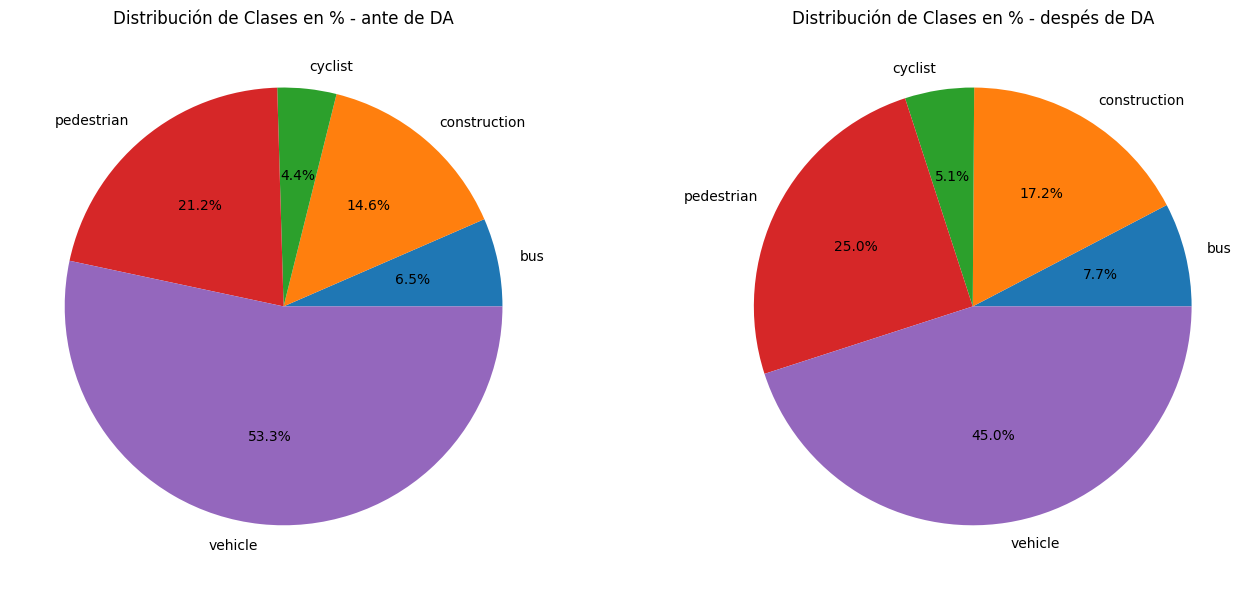

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfica 1 - df_1
axes[0].pie(df_1["cantidad_imagenes"], labels=df_1["clases"], autopct='%1.1f%%')
axes[0].set_title("Distribución de Clases en % - ante de DA")

# Gráfica 2 - df_2
axes[1].pie(df_2["cantidad_imagenes"], labels=df_2["clases"], autopct='%1.1f%%')
axes[1].set_title("Distribución de Clases en % - despés de DA")

plt.tight_layout()
plt.show()

# **Aplicación del modelo "YOLOv8s"**

* **Características de YOLOv8s**

1.   Modelo ligero
      - Tiene menos parametros
      - Requieres menos memoria y menos potencia de GPU
2.   Alta velocidad
      - Ideal para aplicaciones que necesiten procesamiento rápido
3.   Buena presición
      - Mantiene buen equilibrio entre presición y velocidad
4.   Multitarea
      - Detección de objetos
      - Segmentación
      - Clasificación




In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")

archivo_data = "/content/drive/MyDrive/REDES_NEURONALES_2026-1/PROYECTO_VISION_COMPUTADORA/data.yaml"

model.train(
    data = archivo_data,
    epochs=10 # número de veces que se vera la imagen
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA H100 80GB HBM3, 81079MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/REDES_NEURONALES_2026-1/PROYECTO_VISION_COMPUTADORA/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freez

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x798ba24773b0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

## **Métricas:**



**1. Box loss:** mide que tan bien el modelo. coloca la caja alrededor del objeto

**2. cls_loss:** que tan bien distingue entre las clases (camiones, peatones, automoviles, señalamientos de contrucción, ciclistas)

**3. dfl_loss:** también mide la presición de la caja. Es la presición de los bordes de bounding box


## **Métricas de evaluación:**

**1. Precision:** de todas las presiciones que el modelo hizo *precision = 0.77*

**2. Recall:** mide que tan bien el modelo encuentra todos los objetos que reealmente existen *recall = 0.696*

**3. mAP50:** que tan bien el modelo detecta y localiza objetos en una imagen *mAP50 = 0.779*


## **Métricas por clase:**

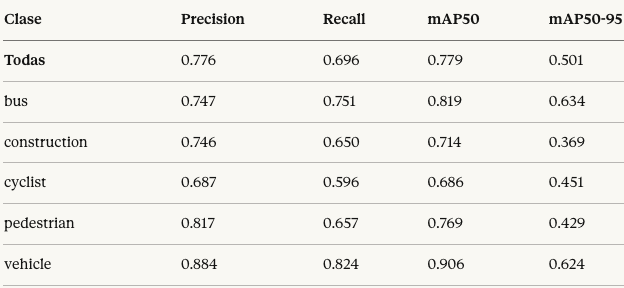

# **Conteo de clases en datos para entrenamiento:**

In [ ]:
import os
from collections import defaultdict

labels_path = "./tesiComputerVisionDataset-1/train/labels/"

conteo_clases = defaultdict(int)

for archivo in os.listdir(labels_path):
    if archivo.endswith(".txt"):
        with open(os.path.join(labels_path, archivo)) as f:
            for linea in f:
                if linea:
                    clase = int(linea[0])
                    conteo_clases[clase] += 1

print("Distribución actual de clases:")
for clase, cantidad in sorted(conteo_clases.items()):
    print(f"  Clase {clase}: {cantidad} instancias")

clase_mayor = max(conteo_clases, key=conteo_clases.get)
clase_menor = min(conteo_clases, key=conteo_clases.get)
ratio = conteo_clases[clase_mayor] / conteo_clases[clase_menor]
print(f"\nRatio de desbalance: 1:{ratio:.1f}")


Distribución actual de clases:
  Clase 0: 4074 instancias
  Clase 1: 35273 instancias
  Clase 2: 3345 instancias
  Clase 3: 43012 instancias
  Clase 4: 191508 instancias

Ratio de desbalance: 1:57.3


# **Oversampling:**

    - Técnica para el desvalance de clases en un dataset, la cual genera ejemplos de clases imagenes minoritarias haciendo un duplicado de ellas. De las siguientes clases:

        - Bus
        - Construction
        - Cyclist
        - Pedestrian
        - Vehicle

In [ ]:
imagenes_rutas = "./tesiComputerVisionDataset-1/train/images"
labels_ruta = "./tesiComputerVisionDataset-1/train/labels"

# Clase dominante que NO queremos duplicar
clase_dominante = 4

clases_a_balancear = {
    0:6000,
    1:10000,
    2:6000
}

for clase_minoritaria, objetivo in clases_a_balancear.items():

    cantidad_actual = conteo_clases[clase_minoritaria]

    if cantidad_actual >= objetivo:
        print(f"Clase {clase_minoritaria}: ya tiene {cantidad_actual} instancias, no es necesario duplicar.")
        continue

    imagenes_sin_dominante = []
    imagenes_con_dominante = []

    for archivo in os.listdir(labels_ruta):
        if archivo.endswith(".txt"):
            with open(os.path.join(labels_ruta, archivo)) as f:
                clases_en_imagen = [int(l[0]) for l in f]

            if not clases_en_imagen:
                continue

            clases_unicas = set(clases_en_imagen)

            if clase_minoritaria not in clases_unicas:
                continue

            if clase_dominante in clases_unicas:
                imagenes_con_dominante.append(archivo.replace(".txt", ""))
            else:
                imagenes_sin_dominante.append(archivo.replace(".txt", ""))

    print(f"\nClase {clase_minoritaria}:")
    print(f"Imágenes sin clase dominante (usables): {len(imagenes_sin_dominante)}")
    print(f"Imágenes con clase dominante (descartadas): {len(imagenes_con_dominante)}")

    if not imagenes_sin_dominante:
        print(f"Todas las imágenes de esta clase aparecen junto a la clase dominante.")
        print(f"No es posible duplicar sin contaminar.")
        continue

    contador = cantidad_actual
    idx = 0
    while contador < objetivo:
        nombre_original = imagenes_sin_dominante[idx % len(imagenes_sin_dominante)]
        sufijo = f"_c{clase_minoritaria}_aug{idx}"

        copiado = False
        for ext in [".jpg"]:
            src_img = os.path.join(imagenes_rutas, nombre_original + ext)
            if os.path.exists(src_img):
                shutil.copy(src_img, os.path.join(imagenes_rutas, nombre_original + sufijo + ext))
                copiado = True
                break

        if copiado:
            src_lbl = os.path.join(labels_ruta, nombre_original + ".txt")
            shutil.copy(src_lbl, os.path.join(labels_ruta, nombre_original + sufijo + ".txt"))
            contador += 1

        idx += 1

    print(f"Clase {clase_minoritaria} aumentada de {cantidad_actual} a {contador} instancias")



Clase 0:
Imágenes sin clase dominante (usables): 60
Imágenes con clase dominante (descartadas): 3127
Clase 0 aumentada de 4074 a 6000 instancias
Clase 1: ya tiene 35273 instancias, no es necesario duplicar.

Clase 2:
Imágenes sin clase dominante (usables): 266
Imágenes con clase dominante (descartadas): 1988
Clase 2 aumentada de 3345 a 6000 instancias


# **Conteo de imagenes por clase después de aplicar Oversampling**

In [ ]:
#Imagenes por clase antes de ADYSO
imagenes_clase_sin_adasyn = {0: 3518, 1: 7910, 2: 2345, 3: 11469, 4: 20664}

#Imagenes por clase después ADASYN

nombre_clases = ['bus','construction','cyclist','pedestrian','vehicle']

conteo_clases_imagenes ={i:0 for i, cadena in enumerate(nombre_clases)}

ruta_principal = "./tesiComputerVisionDataset-1/"

tipo_dataset = {'train':"train/labels"}

for clave, valor in tipo_dataset.items():
    ruta_completa = os.path.join(ruta_principal, valor)
    archivos = os.listdir(ruta_completa)

    for archivo in archivos:
        ruta_archivo = os.path.join(ruta_completa, archivo)
        apariciones_clases = set()

        with open(ruta_archivo, "r") as f:
          for linea in f:
              if linea:
                  clase_numero = int(linea[0])

                  if clase_numero not in apariciones_clases:
                      apariciones_clases.add(clase_numero)
                      conteo_clases_imagenes[clase_numero] += 1

print("Conteo de imagenes por clase después de Oversampling:", conteo_clases_imagenes)

# **Comparación de cantidad de imagenes antes y despues del Oversampling**

In [41]:
#Clases
nombre_clases = ['bus','construction','cyclist','pedestrian','vehicle']

#Imagenes por clase antes de ADYSO
imagenes_clase_sin_adasyn = {0: 3518, 1: 7910, 2: 2345, 3: 11469, 4: 20664}

datos = {
    "clases_id": list(imagenes_clase_sin_adasyn.keys()),
    "clases": list(nombre_clases),
    "cantidad_imagenes": list(imagenes_clase_sin_adasyn.values()),
}

df_1 = pd.DataFrame(datos)

#Imagenes por clase despés de ADYSON
imagenes_clase_adasyn = {0: 6429, 1: 9994, 2: 4909, 3: 11345, 4: 17874}


datos = {
    "clases_id": list(imagenes_clase_adasyn.keys()),
    "clases": list(nombre_clases),
    "cantidad_imagenes": list(imagenes_clase_adasyn.values()),
}

df_2 = pd.DataFrame(datos)

In [42]:
df_resultado = pd.merge(df_1, df_2, on='clases_id', how='outer')

In [43]:
df_resultado[['clases_x','cantidad_imagenes_x','cantidad_imagenes_y']].head()

,clases_x,cantidad_imagenes_x,cantidad_imagenes_y
0,bus,3518,6429
1,construction,7910,9994
2,cyclist,2345,4909
3,pedestrian,11469,11345
4,vehicle,20664,17874


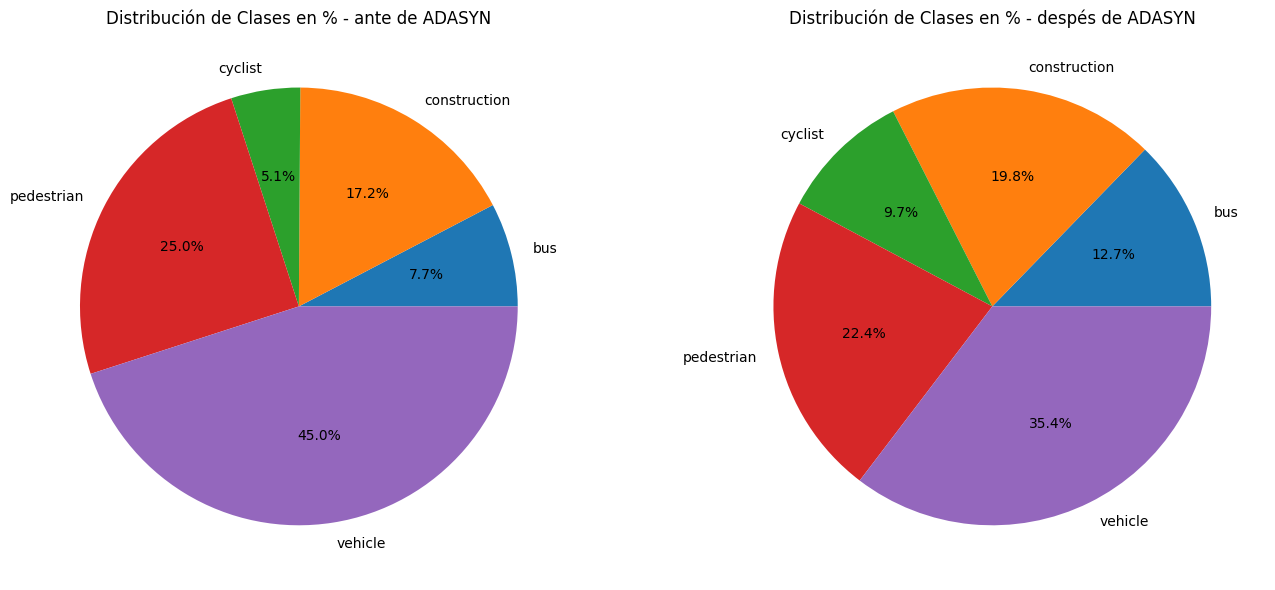

In [44]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfica 1 - df_1
axes[0].pie(df_1["cantidad_imagenes"], labels=df_1["clases"], autopct='%1.1f%%')
axes[0].set_title("Distribución de Clases en % - ante de ADASYN")

# Gráfica 2 - df_2
axes[1].pie(df_2["cantidad_imagenes"], labels=df_2["clases"], autopct='%1.1f%%')
axes[1].set_title("Distribución de Clases en % - despés de ADASYN")

plt.tight_layout()
plt.show()

# **Segunda aplicación de YOLOv8s**

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")

archivo_data = "./data.yaml"

model.train(
    data=archivo_data,
    epochs=10
)

Ultralytics 8.4.21 🚀 Python-3.10.16 torch-2.10.0+cu128 CPU (AMD EPYC 9224 24-Core Processor)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train12, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, p